In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/Documents/projects/Polyhedron`
┌ Warning: Make sure you comply with the NEOS terms of use: http://www.neos-server.org/neos/termofuse.html
└ @ NEOSServer ~/.julia/packages/NEOSServer/2P7PD/src/NEOSServer.jl:14


In [2]:
A = [0 1;
    -0.1 0.95] 
B = [0;
     1;;]

C = [0.025 0.025]

T = 0.4

delta = 0.5

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/2 0
      0 1/2;
     -1/2 0;
      0 -1/2;]
Sv = [1/10;
      -1/10;]

Sw = [1/10;
      -1/10;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/2;
      -1/2;;]

#testando para d = 1
d = 1

1

In [3]:
result_dis = Poly.finding_L_pinvariant_segref_delay(A_exp, B_exp, E_exp, S, R, d, time=5,lf=18,  lambda=0.99)

Job 18711284 dispatched
password: gGszOMkK
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 10 entries:
  "J" => [-183.793 -1023.06 … -2440.78 542.274; -3090.36 -13550.5 … -14625.0 -3…
  "M" => [0.000105915 7.9019e-5 … 7.4813e-5 5.71289e-5; 0.0158867 0.0126002 … 0…
  "P" => [0.00528648 3.91956e-5; 0.014711 0.0102511; … ; 0.0133252 0.010403; 0.…
  "N" => [4.25885e-5 6.98647e-5 … 0.000101515 0.000165918; 0.0159558 0.0125761 …
  "T" => [6.6358e-7 -1.00606e-7 … -1.36044e-7 -3.92893e-7; 0.00454264 0.0004818…
  "G" => [0.0119451 -0.121284 0.0442615 0.036015]
  "K" => [-2.1476e-5 -3.08557e-5 -0.00016867 -1.45202e-6; 0.00426635 -0.0426977…
  "L" => [0.0021355 8.15388e-5 … 7.43589e-5 4.46273e-5; 0.0168548 0.0123186 … 0…
  "F" => [-0.901002 0.843599 0.107957 0.00524728; -0.0836822 0.105681 -0.001172…
  "H" => [0.129287 8.14012e-5 … 7.47058e-5 4.42291e-5; 0.0231166 0.0126578 … 0.…

In [17]:
F = result_dis["F"]
G = result_dis["G"]
K = result_dis["K"]
H = result_dis["H"]
L = result_dis["L"]
M = result_dis["M"]
N = result_dis["N"]
P = result_dis["P"]
T = result_dis["T"]
J = result_dis["J"]

using DelimitedFiles

open("exemplo_cleiton_1.txt", "w") do f
    println(f, "5 min, d = 1, lambda = 0.99")
    println(f, "F")
    writedlm(f, F)
    println(f, "\nG")
    writedlm(f, G)
    println(f, "\nK")
    writedlm(f, K)
    println(f, "\nH")
    writedlm(f, H)
    println(f, "\nL")
    writedlm(f, L)
    println(f, "\nM")
    writedlm(f, M)
    println(f, "\nN")
    writedlm(f, N)
    println(f, "\nP")
    writedlm(f, P)
    println(f, "\nT")
    writedlm(f, T)
    println(f, "\nJ")
    writedlm(f, J)
    println(f, "==============================================")
end

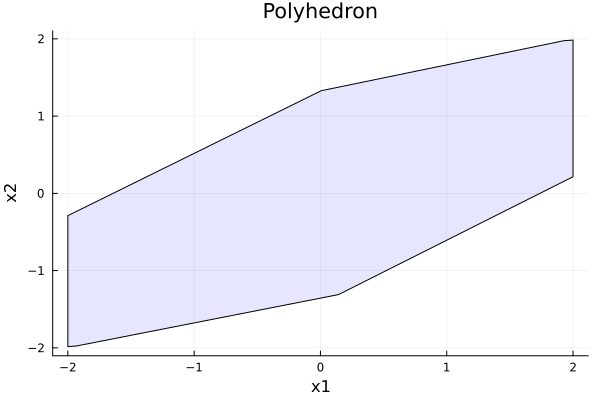

In [6]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(19))

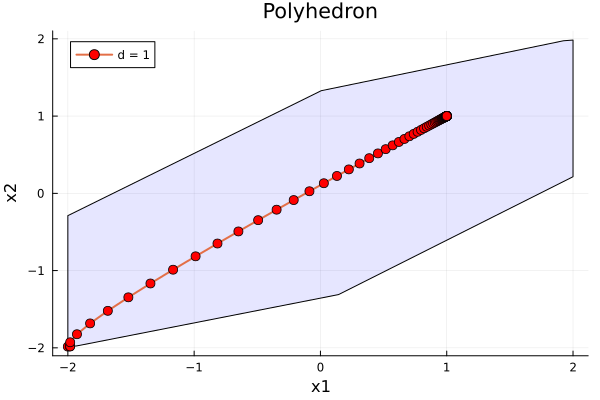

In [10]:
using Plots

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos) # x2 ir para 1 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj1 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)

T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(19))

x1 = [p[1] for p in traj1]
x2 = [p[2] for p in traj1]
v = [p[3] for p in traj1]
w = [p[4] for p in traj1]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")
     


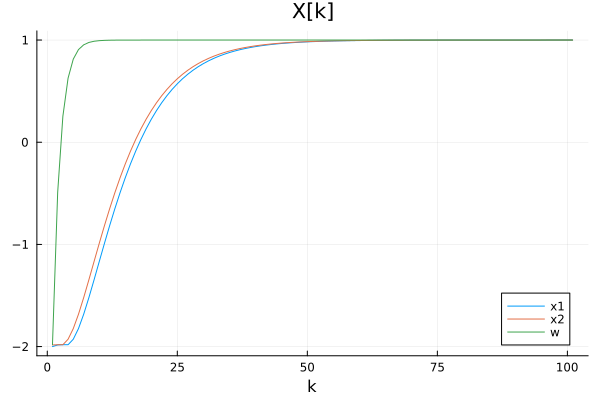

In [11]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

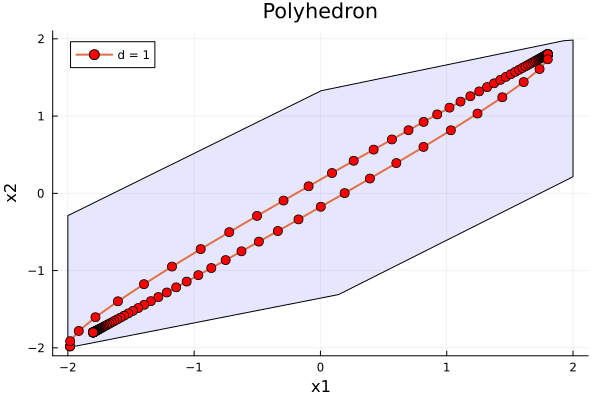

In [13]:
w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos)*1.8 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj18 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)

r = ones(passos)*(-1.8)

traj18_18 = Poly.trajectory_segref_delay(traj18, A_exp, BG, E_exp, r, passos, d; reverse=false)


T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(19))

x1 = [p[1] for p in traj18_18]
x2 = [p[2] for p in traj18_18]
v = [p[3] for p in traj18_18]
w = [p[4] for p in traj18_18]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")
     


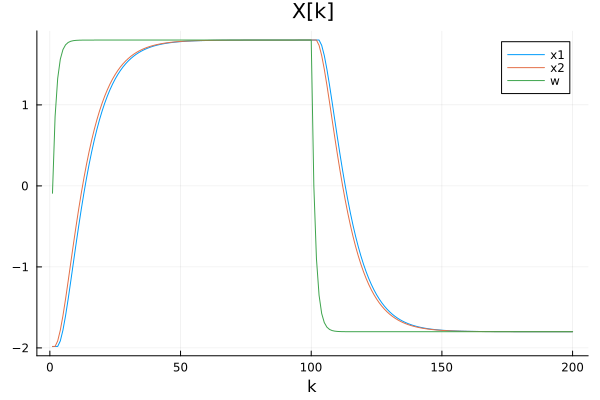

In [14]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

In [21]:
d = 2
result_dis_d2 = Poly.finding_L_pinvariant_segref_delay(A_exp, B_exp, E_exp, S, R, d, time=30,lf=18,  lambda=0.999)

Job 18711397 dispatched
password: VqmoHwvB
---------- Begin Solver Output -----------

Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.



LoadError: Result index of attribute MathOptInterface.VariablePrimal(1) out of bounds. There are currently 0 solution(s) in the model.

In [22]:
F = result_dis_d2["F"]
G = result_dis_d2["G"]
K = result_dis_d2["K"]
H = result_dis_d2["H"]
L = result_dis_d2["L"]
M = result_dis_d2["M"]
N = result_dis_d2["N"]
P = result_dis_d2["P"]
T = result_dis_d2["T"]
J = result_dis_d2["J"]

using DelimitedFiles

open("exemplo_cleiton_2.txt", "w") do f
    println(f, "30 min, d = 2, lambda = 0.999")
    println(f, "F")
    writedlm(f, F)
    println(f, "\nG")
    writedlm(f, G)
    println(f, "\nK")
    writedlm(f, K)
    println(f, "\nH")
    writedlm(f, H)
    println(f, "\nL")
    writedlm(f, L)
    println(f, "\nM")
    writedlm(f, M)
    println(f, "\nN")
    writedlm(f, N)
    println(f, "\nP")
    writedlm(f, P)
    println(f, "\nT")
    writedlm(f, T)
    println(f, "\nJ")
    writedlm(f, J)
    println(f, "==============================================")
end

LoadError: UndefVarError: `result_dis_d2` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [23]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(18))

LoadError: DimensionMismatch: incompatible dimensions for matrix multiplication: tried to multiply a matrix of size (265, 19) with a vector of length 18. The second dimension of the matrix: 19, does not match the length of the vector: 18.

In [24]:
using Plots

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos) # x2 ir para 1 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj1 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)

T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(18))

x1 = [p[1] for p in traj1]
x2 = [p[2] for p in traj1]
v = [p[3] for p in traj1]
w = [p[4] for p in traj1]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")

LoadError: DimensionMismatch: incompatible dimensions for matrix multiplication: tried to multiply a matrix of size (265, 19) with a vector of length 18. The second dimension of the matrix: 19, does not match the length of the vector: 18.

In [25]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

LoadError: DimensionMismatch: number of rows of each array must match (got (200, 19))

In [26]:
w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos)*1.8 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj18 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)

r = ones(passos)*(-1.8)

traj18_18 = Poly.trajectory_segref_delay(traj18, A_exp, BG, E_exp, r, passos, d; reverse=false)


T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(18))

x1 = [p[1] for p in traj18_18]
x2 = [p[2] for p in traj18_18]
v = [p[3] for p in traj18_18]
w = [p[4] for p in traj18_18]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")
     


LoadError: DimensionMismatch: incompatible dimensions for matrix multiplication: tried to multiply a matrix of size (265, 19) with a vector of length 18. The second dimension of the matrix: 19, does not match the length of the vector: 18.

In [27]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

LoadError: DimensionMismatch: number of rows of each array must match (got (200, 19))

In [28]:
d = 1
result_dis_d2 = Poly.finding_L_pinvariant_segref_delay(A_exp, B_exp, E_exp, S, R, d, time=30,lf=18,  lambda=0.99)

Job 18711501 dispatched
password: BtRMLrPG
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'

Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 10 entries:
  "J" => [2444.0 2426.87 … 2733.67 2442.14; 69.9519 -75.0032 … -30.4062 40.5475…
  "M" => [0.0010471 0.00111635 … 0.00103313 0.00106225; 0.000351497 0.000201365…
  "P" => [0.000539101 0.039447; 0.00464786 0.000137569; … ; -0.000466323 -0.000…
  "N" => [0.00107901 0.00107037 … 0.00107924 0.00107918; 0.000251747 0.00028168…
  "T" => [0.0511607 0.052901 … 0.0513232 0.0508548; 0.0520898 0.0533467 … 0.051…
  "G" => [0.00573366 -0.0474963 7.83193e-5 0.000118973]
  "K" => [0.0100287 -0.0861238 6.41494e-5 7.41858e-5; 0.00714902 -0.0595459 -0.…
  "L" => [0.0117471 0.00054734 … 0.320767 0.007232; 0.000142494 0.0103512 … 0.0…
  "F" => [-0.521476 2.7417 -0.0767362 -0.0389079; 0.866676 0.910498 0.0858447 0…
  "H" => [0.0170718 0.00049791 … 0.342496 0.00678357; 0.000144511 0.106177 … 0.…

In [29]:
F = result_dis_d2["F"]
G = result_dis_d2["G"]
K = result_dis_d2["K"]
H = result_dis_d2["H"]
L = result_dis_d2["L"]
M = result_dis_d2["M"]
N = result_dis_d2["N"]
P = result_dis_d2["P"]
T = result_dis_d2["T"]
J = result_dis_d2["J"]

using DelimitedFiles

open("exemplo_cleiton_3.txt", "w") do f
    println(f, "30 min, d = 1, lambda = 0.99")
    println(f, "F")
    writedlm(f, F)
    println(f, "\nG")
    writedlm(f, G)
    println(f, "\nK")
    writedlm(f, K)
    println(f, "\nH")
    writedlm(f, H)
    println(f, "\nL")
    writedlm(f, L)
    println(f, "\nM")
    writedlm(f, M)
    println(f, "\nN")
    writedlm(f, N)
    println(f, "\nP")
    writedlm(f, P)
    println(f, "\nT")
    writedlm(f, T)
    println(f, "\nJ")
    writedlm(f, J)
    println(f, "==============================================")
end

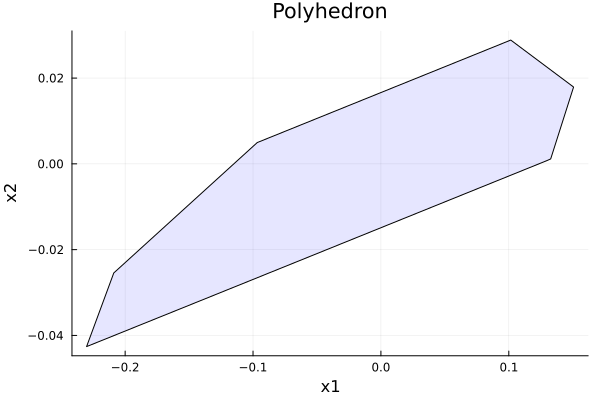

In [30]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(18))

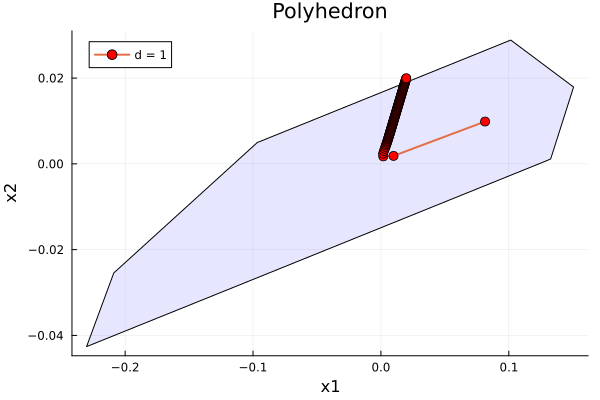

In [31]:
using Plots

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos) # x2 ir para 1 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj1 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)

T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(18))

x1 = [p[1] for p in traj1]
x2 = [p[2] for p in traj1]
v = [p[3] for p in traj1]
w = [p[4] for p in traj1]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")

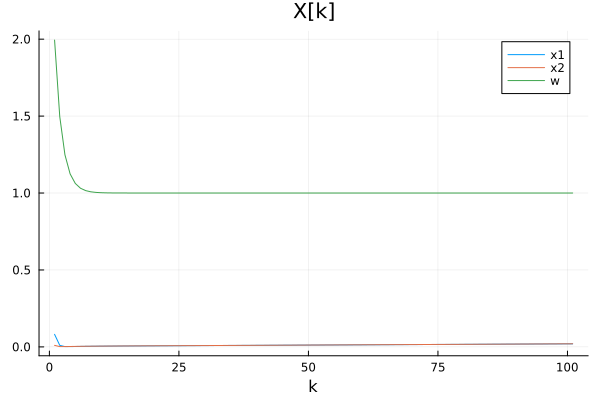

In [32]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

In [33]:
w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos)*1.8 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj18 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)

r = ones(passos)*(-1.8)

traj18_18 = Poly.trajectory_segref_delay(traj18, A_exp, BG, E_exp, r, passos, d; reverse=false)


T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(18))

x1 = [p[1] for p in traj18_18]
x2 = [p[2] for p in traj18_18]
v = [p[3] for p in traj18_18]
w = [p[4] for p in traj18_18]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")
     


LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///home/nicholaswallace/Documents/projects/Polyhedron/In[33]#33:19\[90mIn[33]:33:19[0;0m]8;;\
     xlabel="k",  
     title="X[k]")[48;2;120;70;70m[0;0m
[90m#                 └ ── [0;0m[91mExpected `)` or `,`[0;0m

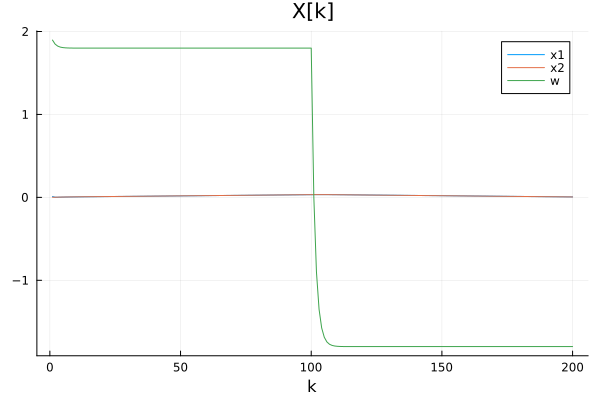

In [34]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")